# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

The "Who" when talking about cybersecurity would be anyone with a computer. The "What" is talking about the cyberattacks that are being carried out the most against the people. The "How" is how people can protect themselves from attacks.

# 3. Homework - work with your own data

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [14]:
# Import the dataset and make DataFrame
df_cyber_events = pd.read_csv('cyber_events.csv', encoding='ISO-8859-1', dtype={'change_log': str})

In [21]:
# Show the head of the dataset
df_cyber_events.iloc[0:5]

,slug,original_method,event_date,reported_date,year,month,actor,actor_type,organization,industry_code,...,opec,gulf_coop,g7,g20,aukus,csto,oecd,osce,five_eyes,change_log
0,1f72c2eb8ab303e4,1,1/1/14,NaN,2014,1,Undetermined,Criminal,Barry University,61,...,0,0,1,1,1,0,1,1,1,[2026-03-02 15:45:26] Pipeline run: parsed MM/...
1,ecac8b3e60a2f72f,1,1/1/14,NaN,2014,1,Undetermined,Criminal,Record Assist LLC,54,...,0,0,1,1,1,0,1,1,1,[2026-03-02 15:45:26] Pipeline run: parsed MM/...
2,3bbe0695e2d019f3,1,1/1/14,NaN,2014,1,Syrian Electronic Army,Hacktivist,Skype's Social Media,54,...,0,0,1,1,1,0,1,1,1,[2026-03-02 15:45:26] Pipeline run: parsed MM/...
3,6100014f6ca84b3d,1,1/2/14,NaN,2014,1,Undetermined,Criminal,Snapchat,51,...,0,0,1,1,1,0,1,1,1,[2026-03-02 15:45:26] Pipeline run: parsed MM/...
4,3a94b8cf6dde1f66,1,1/3/14,NaN,2014,1,DERP Trolling,Undetermined,Battle.net,51,...,0,0,1,1,1,0,1,1,1,[2026-03-02 15:45:26] Pipeline run: parsed MM/...


In [15]:
# Summarize with info
df_cyber_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 16532 entries, 0 to 16531
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   slug                16532 non-null  str  
 1   original_method     16532 non-null  int64
 2   event_date          16532 non-null  str  
 3   reported_date       1977 non-null   str  
 4   year                16532 non-null  int64
 5   month               16532 non-null  int64
 6   actor               16532 non-null  str  
 7   actor_type          16532 non-null  str  
 8   organization        16532 non-null  str  
 9   industry_code       16532 non-null  int64
 10  industry            16532 non-null  str  
 11  motive              16532 non-null  str  
 12  event_type          16532 non-null  str  
 13  event_subtype       16532 non-null  str  
 14  magnitude           716 non-null    str  
 15  duration            692 non-null    str  
 16  scope               719 non-null    str  
 17  ip  

In [16]:
# Summarize with describe
df_cyber_events.describe()

,original_method,year,month,industry_code,nato,eu,shanghai_coop,oas,mercosur,au,...,asean,opec,gulf_coop,g7,g20,aukus,csto,oecd,osce,five_eyes
count,16532.000000,16532.000000,16532.000000,16532.000000,16532.000000,16532.000000,16532.000000,16532.000000,16532.000000,16532.000000,...,16532.000000,16532.000000,16532.000000,16532.000000,16532.000000,16532.000000,16532.000000,16532.000000,16532.000000,16532.000000
mean,0.945681,2020.626966,6.384950,63.291132,0.684551,0.138156,0.074159,0.529337,0.013187,0.015304,...,0.025466,0.015364,0.007501,0.628418,0.750242,0.543975,0.036172,0.761553,0.770929,0.573917
std,0.226653,3.181240,3.504469,19.137007,0.464708,0.345074,0.262038,0.499154,0.114077,0.122761,...,0.157540,0.123000,0.086283,0.483242,0.432886,0.498077,0.186724,0.426146,0.420248,0.494521
min,0.000000,2014.000000,1.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2018.000000,3.000000,51.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
50%,1.000000,2021.000000,6.000000,61.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
75%,1.000000,2023.000000,9.000000,81.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,2026.000000,12.000000,99.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [22]:
# Finding duplicate rows (when would this be approprite)
df[df_cyber_events.duplicated(keep=False)]

,slug,original_method,event_date,reported_date,year,month,actor,actor_type,organization,industry_code,...,opec,gulf_coop,g7,g20,aukus,csto,oecd,osce,five_eyes,change_log


In [28]:
# Create DataFrame with only numeric columns
df_numeric_cyber = df_cyber_events.select_dtypes(include=[np.number])
df_numeric_cyber.iloc[0:5]

,original_method,year,month,industry_code,nato,eu,shanghai_coop,oas,mercosur,au,...,asean,opec,gulf_coop,g7,g20,aukus,csto,oecd,osce,five_eyes
0,1,2014,1,61,1,0,0,1,0,0,...,0,0,0,1,1,1,0,1,1,1
1,1,2014,1,54,1,0,0,1,0,0,...,0,0,0,1,1,1,0,1,1,1
2,1,2014,1,54,1,0,0,1,0,0,...,0,0,0,1,1,1,0,1,1,1
3,1,2014,1,51,1,0,0,1,0,0,...,0,0,0,1,1,1,0,1,1,1
4,1,2014,1,51,1,0,0,1,0,0,...,0,0,0,1,1,1,0,1,1,1


In [29]:
# What are the mean, median, and mode of each column
# Calculate mean, median, and mode for each column
column_means = df_numeric_cyber.mean()
column_medians = df_numeric_cyber.median()
# Mode returns a DataFrame because a column can have multiple modes, 
# so we select the first row to get a single mode value if one exists
column_modes = df_numeric_cyber.mode().iloc[0] 

print("\nMean of each column:")
print(column_means)

print("\nMedian of each column:")
print(column_medians)

print("\nMode of each column (first value if multiple modes):")
print(column_modes)


Mean of each column:
original_method       0.945681
year               2020.626966
month                 6.384950
industry_code        63.291132
nato                  0.684551
eu                    0.138156
shanghai_coop         0.074159
oas                   0.529337
mercosur              0.013187
au                    0.015304
ecowas                0.002541
asean                 0.025466
opec                  0.015364
gulf_coop             0.007501
g7                    0.628418
g20                   0.750242
aukus                 0.543975
csto                  0.036172
oecd                  0.761553
osce                  0.770929
five_eyes             0.573917
dtype: float64

Median of each column:
original_method       1.0
year               2021.0
month                 6.0
industry_code        61.0
nato                  1.0
eu                    0.0
shanghai_coop         0.0
oas                   1.0
mercosur              0.0
au                    0.0
ecowas                0.0
as

In [30]:
# Are there any missing or null values? Do we want to remove, use the mean, or a value of your choice?
# Shows the number of nulls in each column
df_cyber_events.isnull().sum()

# When looking at the general trends of cyber events, any column that has a null can be removed.
df_cleaned_cyber = df_cyber_events.dropna(axis=1)

In [31]:
# Display the head of the cleaned cyber dataframe
df_cleaned_cyber.iloc[0:5]

,slug,original_method,event_date,year,month,actor,actor_type,organization,industry_code,industry,...,asean,opec,gulf_coop,g7,g20,aukus,csto,oecd,osce,five_eyes
0,1f72c2eb8ab303e4,1,1/1/14,2014,1,Undetermined,Criminal,Barry University,61,Educational Services,...,0,0,0,1,1,1,0,1,1,1
1,ecac8b3e60a2f72f,1,1/1/14,2014,1,Undetermined,Criminal,Record Assist LLC,54,"Professional, Scientific, and Technical Services",...,0,0,0,1,1,1,0,1,1,1
2,3bbe0695e2d019f3,1,1/1/14,2014,1,Syrian Electronic Army,Hacktivist,Skype's Social Media,54,"Professional, Scientific, and Technical Services",...,0,0,0,1,1,1,0,1,1,1
3,6100014f6ca84b3d,1,1/2/14,2014,1,Undetermined,Criminal,Snapchat,51,Information,...,0,0,0,1,1,1,0,1,1,1
4,3a94b8cf6dde1f66,1,1/3/14,2014,1,DERP Trolling,Undetermined,Battle.net,51,Information,...,0,0,0,1,1,1,0,1,1,1


In [ ]:
# Find any inconsistent data?
# For a cyber event, we already looked at all of the inconsistent data. There are undetermined values in some columns, but when dealing
# with cyber events. It is mostly not known.

In [ ]:
# Encode any categorical values with one hot encoding with actor type
df_encoded_cyber = pd.get_dummies(df_cleaned_cyber, columns=['actor_type'], prefix=[''], prefix_sep='')

# Convert the boolean output to integers (0 or 1)
# Some pandas versions might output True/False instead of 1/0
account_cols = ['Criminal', 'Undetermined', 'Hacktivist', 'Hobbyist', 'Nation-State', 'Terrorist'] # Names depending on your original data values
df_encoded_cyber[account_cols] = df_encoded_cyber[account_cols].astype(int)

# Display the result
df_encoded_cyber.head()

,slug,original_method,event_date,year,month,actor,organization,industry_code,industry,motive,...,csto,oecd,osce,five_eyes,Criminal,Hacktivist,Hobbyist,Nation-State,Terrorist,Undetermined
0,1f72c2eb8ab303e4,1,1/1/14,2014,1,Undetermined,Barry University,61,Educational Services,Undetermined,...,0,1,1,1,1,0,0,0,0,0
1,ecac8b3e60a2f72f,1,1/1/14,2014,1,Undetermined,Record Assist LLC,54,"Professional, Scientific, and Technical Services",Undetermined,...,0,1,1,1,1,0,0,0,0,0
2,3bbe0695e2d019f3,1,1/1/14,2014,1,Syrian Electronic Army,Skype's Social Media,54,"Professional, Scientific, and Technical Services",Protest,...,0,1,1,1,0,1,0,0,0,0
3,6100014f6ca84b3d,1,1/2/14,2014,1,Undetermined,Snapchat,51,Information,Undetermined,...,0,1,1,1,1,0,0,0,0,0
4,3a94b8cf6dde1f66,1,1/3/14,2014,1,DERP Trolling,Battle.net,51,Information,Undetermined,...,0,1,1,1,0,0,0,0,0,1


In [39]:
columns_to_convert = ['Criminal', 'Undetermined', 'Hacktivist', 'Hobbyist', 'Nation-State', 'Terrorist']

for col in columns_to_convert:

    # Convert to numeric, then to integer
    df_encoded_cyber[col] = pd.to_numeric(df_encoded_cyber[col]).astype(int)

# Verify the changes
print(df_encoded_cyber.dtypes)

slug                 str
original_method    int64
event_date           str
year               int64
month              int64
actor                str
organization         str
industry_code      int64
industry             str
motive               str
event_type           str
event_subtype        str
country              str
actor_country        str
nato               int64
eu                 int64
shanghai_coop      int64
oas                int64
mercosur           int64
au                 int64
ecowas             int64
asean              int64
opec               int64
gulf_coop          int64
g7                 int64
g20                int64
aukus              int64
csto               int64
oecd               int64
osce               int64
five_eyes          int64
Criminal           int64
Hacktivist         int64
Hobbyist           int64
Nation-State       int64
Terrorist          int64
Undetermined       int64
dtype: object


# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data (p. 1-17). Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

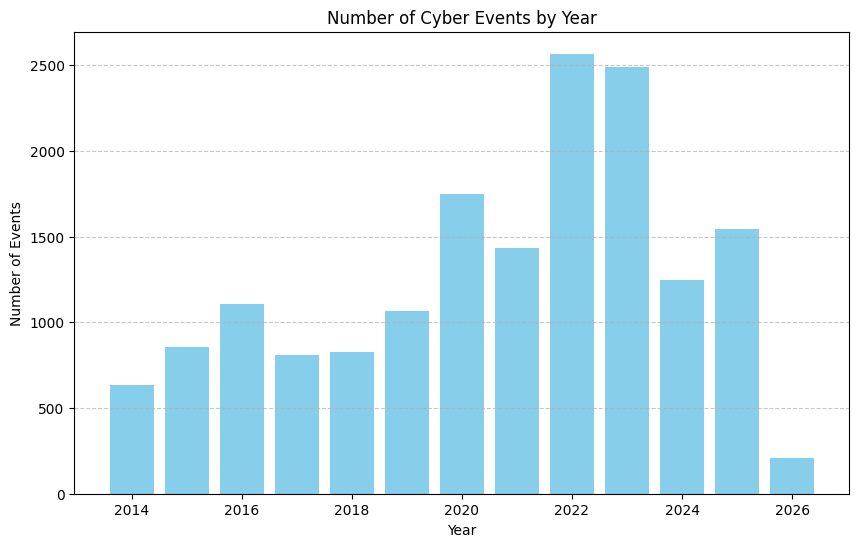

In [40]:
# Showing cyber incidents per year
import matplotlib.pyplot as plt

# Extract year from date and count events per year
yearly_counts = df_cleaned_cyber['year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(yearly_counts.index, yearly_counts.values, color='skyblue')
plt.title('Number of Cyber Events by Year')
plt.xlabel('Year')
plt.ylabel('Number of Events')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()